In [47]:
from typing import Optional, Dict, Any, List, Callable, Tuple
import json
import sys
import os
import requests
import numpy as np
import pandas as pd
import importlib
import importlib.util
from datetime import datetime, date
import warnings

MHW_API_JSON = "https://eco.odb.ntu.edu.tw/api/mhw"


In [ ]:
def _parse_bbox(bbox: Optional[str]) -> Dict[str, Any]:
    if not bbox:
        return {}
    parts = [x.strip() for x in bbox.split(",") if x.strip()]
    if len(parts) not in (2,4):
        print("Invalid --bbox. Use lon0,lat0[,lon1,lat1].", file=sys.stderr)
        return {}
    out = {"lon0": float(parts[0]), "lat0": float(parts[1])}
    if len(parts) == 4:
        out["lon1"] = float(parts[2]); out["lat1"] = float(parts[3])
    return out

def _build_args_from_tokens(tokens: List[str]) -> Dict[str, Any]:
    """
    Simple inline parser for: /mhw [free-text intent] [flags]
    Flags:
      --bbox lon0,lat0[,lon1,lat1]
      --start YYYY-MM-DD
      --end YYYY-MM-DD
      --fields sst,sst_anomaly,level,td
      --csv
      --raw
      --plot series|month|map
      --plot-field sst|sst_anomaly|level|td
      --periods "YYYY,YYYY-YYYY,YYYYMM,YYYYMM-YYYYMM,YYYYMMDD-YYYYMMDD"
      --map-method cartopy|basemap|plain
      --cmap NAME                  # override colormap
      --vmin FLOAT                 # override
      --vmax FLOAT                 # override
      --outfile path.png
    """

    args: Dict[str, Any] = {}
    freeform: List[str] = []

    i = 0
    while i < len(tokens):
        t = tokens[i]
        if t == "--bbox" and i+1 < len(tokens):
            args.update(_parse_bbox(tokens[i+1])); i += 2; continue
        if t == "--start" and i+1 < len(tokens):
            args["start"] = tokens[i+1]; i += 2; continue
        if t == "--end" and i+1 < len(tokens):
            args["end"] = tokens[i+1]; i += 2; continue
        if t == "--fields" and i+1 < len(tokens):
            args["append"] = tokens[i+1]; i += 2; continue
        if t == "--csv":
            args["output"] = "csv"; i += 1; continue
        if t == "--raw":
            args["return_raw"] = True; i += 1; continue
        if t == "--plot" and i+1 < len(tokens):
            args["_plot_mode"] = tokens[i+1]; i += 2; continue
        if t == "--plot-field" and i+1 < len(tokens):
            args["_plot_field"] = tokens[i+1]; i += 2; continue
        if t == "--periods" and i+1 < len(tokens):
            args["_periods"] = tokens[i+1]; i += 2; continue
        if t == "--outfile" and i+1 < len(tokens):
            args["_outfile"] = tokens[i+1]; i += 2; continue
        if t == "--map-method" and i+1 < len(tokens):
            args["_map_method"] = tokens[i+1]; i += 2; continue
        if t == "--cmap" and i+1 < len(tokens):
            args["_cmap"] = tokens[i+1]; i += 2; continue
        if t == "--vmin" and i+1 < len(tokens):
            try: args["_vmin"] = float(tokens[i+1])
            except: args["_vmin"] = None
            i += 2; continue
        if t == "--vmax" and i+1 < len(tokens):
            try: args["_vmax"] = float(tokens[i+1])
            except: args["_vmax"] = None
            i += 2; continue
        # collect free-form
        freeform.append(t); i += 1

    if freeform:
        args["user_intent"] = " ".join(freeform)
    return args


tokens = ("--bbox 135,-25,-60,25 --fields sst_anomaly --plot map --plot-field sst_anomaly --start 2007-12 --map-method basemap").strip().split()
pargs = _build_args_from_tokens(tokens)

print(pargs)


{'lon0': 135.0, 'lat0': -25.0, 'lon1': -60.0, 'lat1': 25.0, 'append': 'sst_anomaly', '_plot_mode': 'map', '_plot_field': 'sst_anomaly', 'start': '2007-12', '_map_method': 'basemap'}


In [7]:
def _strip_quotes(s: str) -> str:
    if not s:
        return s
    quotes = {'"', "'", 'â€œ', 'â€�', 'â€˜', 'â€™'}
    out = s.strip()
    while len(out) >= 2 and out[0] in quotes and out[-1] in quotes:
        out = out[1:-1].strip()
    return out

def _convert_to_day(date_str: str) -> str:
    """
    Convert various compact date strings to 'YYYY-MM-DD'.
    Accepts: YYYY-MM-DD, YYYYMMDD, YYYY-MM, YYYYMM, YYYY.
    Returns YYYY-MM-DD (first day for YYYY/YYYMM forms).
    """
    s = _strip_quotes((date_str or '').strip())
    # Try precise formats first
    for fmt in ("%Y-%m-%d", "%Y%m%d"):
        try:
            return datetime.strptime(s, fmt).strftime("%Y-%m-%d")
        except ValueError:
            pass
    # Month-only
    for fmt in ("%Y-%m", "%Y%m"):
        try:
            dt = datetime.strptime(s, fmt)
            return dt.strftime("%Y-%m-01")
        except ValueError:
            pass
    # Year-only
    if len(s) == 4 and s.isdigit():
        try:
            return datetime.strptime(s, "%Y").strftime("%Y-01-01")
        except ValueError:
            pass
    raise ValueError(f"Invalid date format: {date_str}")

def _normalize_start_end_inplace(args: Dict[str, Any]) -> None:
    if "start" in args and args.get("start"):
        try: args["start"] = _convert_to_day(args["start"])
        except Exception: pass
    if "end" in args and args.get("end"):
        try: args["end"] = _convert_to_day(args["end"])
        except Exception: pass

_normalize_start_end_inplace(pargs)
print(pargs)

{'lon0': 135.0, 'lat0': -25.0, 'lon1': -60.0, 'lat1': 25.0, 'append': 'sst_anomaly', '_plot_mode': 'map', '_plot_field': 'sst_anomaly', 'start': '2007-12-01', '_map_method': 'basemap'}


In [ ]:
base_args = {k: v for k, v in pargs.items() if not k.startswith("_")}
res = None
bounds_list: List[Tuple[str, str, str]] = [] 
params_base = {k: v for k, v in pargs.items() if k in {"lon0","lat0","lon1","lat1","append"}}
out_meta: List[Dict[str, Any]] = []
all_records: List[Dict[str, Any]] = []
if not bounds_list:
    s = pargs.get("start")
    e = pargs.get("end")
    if not s:
        pass
    if not e:
        e = s
    #if not (s and e) and pargs.get("_periods"):
    #    s, e = _overall_bounds_from_periods(pargs.get("_periods", ""))
    else:
        bounds_list = [(f"{s}-{e}", s, e)]

print(params_base, bounds_list)

{'lon0': 135.0, 'lat0': -25.0, 'lon1': -60.0, 'lat1': 25.0, 'append': 'sst_anomaly'} [('2007-12-01-2007-12-01', '2007-12-01', '2007-12-01')]


In [25]:
ANTIMERIDIAN_EPS = 0.001  # small fudge so endpoints are inside valid tiles

def _norm_lon180(x: float) -> float:
    x = ((x + 180.0) % 360.0) - 180.0
    if x == -180.0:
        return 180.0
    return x

def _split_bbox_antimeridian(args: Dict[str, Any]) -> list[Dict[str, Any]]:
    """
    If bbox crosses 180Â°, return two param dicts:
      [pos_lon, 180-Îµ] and [-180+Îµ, neg_lon]   (both in [-180, 180])
    Otherwise return [args] unchanged.
    """

    if "lon1" not in args or "lat1" not in args:
        return [dict(args)]  # point query â†’ no split

    lo0_raw = float(args["lon0"]); lo1_raw = float(args["lon1"])
    la0 = float(args["lat0"]);     la1 = float(args["lat1"])

    lo0 = _norm_lon180(lo0_raw); lo1 = _norm_lon180(lo1_raw)
    if abs(lo1 - lo0) <= 180.0:
        return [dict(args)]

    # identify positive and negative endpoints
    if lo0 >= 0 and lo1 < 0:
        pos_lon, neg_lon = lo0, lo1
    elif lo1 >= 0 and lo0 < 0:
        pos_lon, neg_lon = lo1, lo0
    else:
        pos_lon = max(lo0, lo1)
        neg_lon = min(lo0, lo1)

    left = dict(args)
    left["lon0"] = pos_lon
    left["lon1"] = 180.0 - ANTIMERIDIAN_EPS
    left["lat0"] = la0; left["lat1"] = la1

    right = dict(args)
    right["lon0"] = -180.0 + ANTIMERIDIAN_EPS
    right["lon1"] = neg_lon
    right["lat0"] = la0; right["lat1"] = la1
    print("[notice] bbox crosses 180Â° â€” fetching in two parts and merging.")

    return [left, right]

In [26]:
def _http_json(params: Dict[str, Any]) -> Dict[str, Any]:
    r = requests.get(MHW_API_JSON, params=params, timeout=60)
    r.raise_for_status()
    df = pd.DataFrame(r.json())
    print(df.head(), df.shape)
    return {"data": r.json(), "endpoint": MHW_API_JSON, "params": params}

In [28]:
# params_base = {k: v for k, v in pargs.items() if k in {"lon0","lat0","lon1","lat1","append"}}
out_meta: List[Dict[str, Any]] = []
all_records: List[Dict[str, Any]] = []

if True:
            for label, s, e in bounds_list:
                base_for_period = dict(base_args)
                if s: base_for_period["start"] = s
                if e: base_for_period["end"]   = e
                # split at 180 if needed
                for part in _split_bbox_antimeridian(base_for_period):
                    part["return_raw"] = True
                    # try:
                        #r = await _call_mcp_tool("mhw_query", part)
                    # except Exception:
                        # r = None
                    # if r and isinstance(r, dict) and "data" in r:
                    #     all_records.extend(r.get("data") or [])
                    #     out_meta.append({"endpoint": r.get("endpoint"),
                    #                      "params": r.get("params"),
                    #                     "label": label})
                    # else:
                    p = {k: v for k, v in part.items()
                        if k in {"lon0","lat0","lon1","lat1","append","start","end"}}
                    print(p)
                    http_res = _http_json(p)
                    out_meta.append({k: v for k, v in http_res.items()
                                     if k != "data"} | {"label": label})
                    all_records.extend(http_res.get("data") or [])


[notice] bbox crosses 180Â° â€” fetching in two parts and merging.
{'lon0': 135.0, 'lat0': -25.0, 'lon1': 179.999, 'lat1': 25.0, 'append': 'sst_anomaly', 'start': '2007-12-01', 'end': '2007-12-01'}
       lon     lat        date  sst_anomaly
0  152.625 -24.875  2007-12-01      -0.3896
1  152.875 -24.875  2007-12-01      -0.3063
2  153.125 -24.875  2007-12-01      -0.1522
3  153.375 -24.875  2007-12-01       0.0006
4  153.625 -24.875  2007-12-01       0.0977 (32708, 4)
{'lon0': -179.999, 'lat0': -25.0, 'lon1': -60.0, 'lat1': 25.0, 'append': 'sst_anomaly', 'start': '2007-12-01', 'end': '2007-12-01'}
       lon     lat        date  sst_anomaly
0 -179.875 -24.875  2007-12-01      -0.0471
1 -179.625 -24.875  2007-12-01      -0.0969
2 -179.375 -24.875  2007-12-01      -0.1852
3 -179.125 -24.875  2007-12-01      -0.2768
4 -178.875 -24.875  2007-12-01      -0.3779 (84251, 4)


In [35]:
def _records_to_df(records: List[Dict[str, Any]]) -> pd.DataFrame:
    df = pd.DataFrame.from_records(records)
    if "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"])
    return df

df = _records_to_df(all_records)

data = df.copy()
data["date"] = pd.to_datetime(data["date"])
data['lon_360'] = data['lon'].apply(lambda x: x + 360 if x < 0 else x) # basemap needs 0-360 degrees longitude
print(data.head(), data.shape)
print(data["lon"].max(), data["lon"].min())

       lon     lat       date  sst_anomaly  lon_360
0  152.625 -24.875 2007-12-01      -0.3896  152.625
1  152.875 -24.875 2007-12-01      -0.3063  152.875
2  153.125 -24.875 2007-12-01      -0.1522  153.125
3  153.375 -24.875 2007-12-01       0.0006  153.375
4  153.625 -24.875 2007-12-01       0.0977  153.625 (116959, 5)
179.625 -179.875


In [34]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
from matplotlib.dates import DateFormatter
from matplotlib import cm
from mpl_toolkits.basemap import Basemap

In [40]:
# Reshape to grid for plotting (matrix-like dataframe: column is longitude, row is latitude, just like the grids in our result plot)
def reshape_to_grid_fixed(data, column, date, lon_col='lon'):
    data_filtered = data[data["date"] == date]
    all_lats = np.sort(data["lat"].unique())     # extract each latitude (every 0.25 degree)
    all_lons = np.sort(data[lon_col].unique())    # extract each longitude (every 0.25 degree)
    grid = pd.DataFrame(index=all_lats, columns=all_lons)
    for _, row in data_filtered.iterrows():
        grid.at[row["lat"], row[lon_col]] = row[column]
    return grid.astype(float)

start = pargs.get("start")
print(start)
grid = reshape_to_grid_fixed(data, 'sst_anomaly', start, lon_col='lon_360') # package Basemap accept 0-360 degree, so we need to convert it
print(grid.tail())
     


2007-12-01
        135.125  135.375  135.625  135.875  136.125  136.375  136.625  \
23.875   1.7531   1.8582   1.9113   1.9267   1.8997   1.8697   1.8019   
24.125   1.6862   1.7756   1.8356   1.8694   1.8616   1.8102   1.7369   
24.375   1.3525   1.4342   1.5002   1.5590   1.5953   1.5676   1.5185   
24.625   0.7915   0.8438   0.9014   0.9674   1.0329   1.0542   1.0795   
24.875   0.2681   0.2775   0.2988   0.3461   0.4039   0.4687   0.5660   

        136.875  137.125  137.375  ...  297.625  297.875  298.125  298.375  \
23.875   1.7190   1.6288   1.5484  ...   0.1542   0.2673   0.3876   0.4868   
24.125   1.6756   1.6214   1.5326  ...   0.1657   0.2401   0.3222   0.3720   
24.375   1.5091   1.5082   1.4260  ...   0.1347   0.1525   0.1547   0.1307   
24.625   1.1420   1.2073   1.1540  ...   0.1096   0.0591  -0.0118  -0.0864   
24.875   0.6614   0.7363   0.7421  ...   0.1346   0.0457  -0.0593  -0.1429   

        298.625  298.875  299.125  299.375  299.625  299.875  
23.875   0.5229   

In [ ]:
def plot_ssta_grid(grid, date, lon0, lon1, lat0, lat1):
    plt.figure(figsize=(12, 5))
    fig, ax = plt.subplots(figsize=(12, 4))
    m = Basemap(projection="cyl", llcrnrlon=lon0, urcrnrlon=lon1,
                llcrnrlat=lat0, urcrnrlat=lat1, resolution="l", ax=ax)
    m.drawcoastlines()
    m.drawparallels(np.arange(lat0, lat1+1, 5), labels=[1,0,0,0])
    m.drawmeridians(np.arange(lon0, lon1+1, 10), labels=[0,0,0,1])
    m.drawmapboundary(fill_color='white')

    # 經緯度格點
    lon2d, lat2d = np.meshgrid(grid.columns.astype(float), grid.index.astype(float))

    # 繪製底圖 We need fill each grid with colors by SST anomaly values in the `grid` dataframe
    cs = m.contourf(lon2d, lat2d, grid.values.astype(float), cmap=cm.RdYlBu_r,
             levels=np.linspace(-3, 3, 21), extend='both', latlon=True)

    cbar = plt.colorbar(cs, orientation="vertical", shrink=0.8, pad=0.02)
    cbar.set_label("SST Anomaly (°C)")
    plt.title(f"SST Anomalies in Central Pacific (Nino3.4) - {date.strftime('%b %Y')}")
    plt.tight_layout()
    plt.show()

<Figure size 1200x500 with 0 Axes>

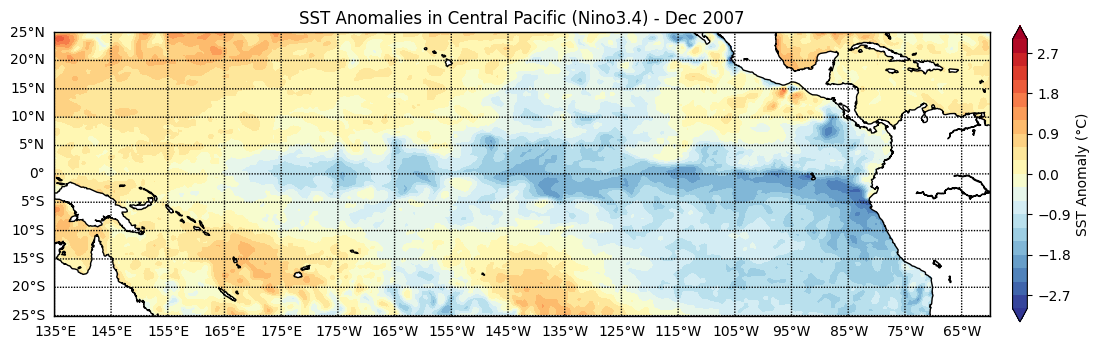

In [64]:
lon0 = pargs.get("lon0")
lon1 = pargs.get("lon1")+360
lat0 = pargs.get("lat0")
lat1 = pargs.get("lat1")
plot_ssta_grid(grid, pd.to_datetime(start), pargs.get("lon0"), pargs.get("lon1")+360, pargs.get("lat0"), pargs.get("lat1"))
     


In [43]:
def _default_cmap_norm(field: str):
    import matplotlib.colors as mcolors
    if field == "sst":
        return "turbo", mcolors.Normalize(vmin=0, vmax=35)
    if field == "sst_anomaly":
        return "RdYlBu_r", mcolors.TwoSlopeNorm(vmin=-5, vcenter=0, vmax=5)
    if field == "level":
        # 0..5 (6 bins) → 6 colors including "extreme"
        colors = ["#ffffff","#f5c268","#ec6b1a","#cb3827","#7f1416","#4b0f13"]
        cmap = mcolors.ListedColormap(colors, name="mhw_levels")
        boundaries = np.arange(-0.5, 5.6, 1.0)  # 6 bins for 0,1,2,3,4,5
        norm = mcolors.BoundaryNorm(boundaries=boundaries, ncolors=cmap.N)
        return cmap, norm
    if field == "td":
        # Diverging around 0; users often want positive only → suggest --vmin 0
        return "BrBG", mcolors.TwoSlopeNorm(vmin=-2000, vcenter=0, vmax=2000)
    return "viridis", None


In [44]:
_PARSE = ("%Y-%m-%d","%Y%m%d","%Y-%m","%Y%m","%Y")

def _pick_month_from(df: pd.DataFrame, start: str | None) -> pd.Timestamp:
    if "date" not in df.columns:
        raise ValueError("DataFrame must include 'date'")
    if not pd.api.types.is_datetime64_any_dtype(df["date"]):
        df["date"] = pd.to_datetime(df["date"])
    if start:
        s = start.strip()
        for fmt in _PARSE:
            try:
                dt = pd.to_datetime(s, format=fmt)
                return pd.Timestamp(dt.year, dt.month, 1)
            except Exception:
                pass
        dt = pd.to_datetime(s)
        return pd.Timestamp(dt.year, dt.month, 1)
    d0 = df["date"].min()
    return pd.Timestamp(d0.year, d0.month, 1)


In [66]:
def _grid_month(df: pd.DataFrame, field: str, month: pd.Timestamp, lon_mode: str = "native"):
    sel = df[df["date"].dt.to_period("M") == month.to_period("M")].copy()
    if sel.empty:
        raise ValueError(f"No data for month {month.strftime('%Y-%m')}")
    if lon_mode == "360":
        sel["lon_plot"] = sel["lon"].apply(lambda x: x + 360 if x < 0 else x)
    else:
        sel["lon_plot"] = sel["lon"]
    lats = np.sort(sel["lat"].unique())
    lons = np.sort(sel["lon_plot"].unique())
    Z = np.full((lats.size, lons.size), np.nan, dtype=float)
    lat_idx = {v:i for i,v in enumerate(lats)}
    lon_idx = {v:i for i,v in enumerate(lons)}
    for lo, la, val in sel[["lon_plot","lat",field]].dropna().itertuples(index=False):
        Z[lat_idx[la], lon_idx[lo]] = val
    LON, LAT = np.meshgrid(lons, lats)
    # grid = pd.DataFrame(index=lats, columns=lons)
    # for _, row in sel.iterrows():
    #     grid.at[row["lat"], row["lon_plot"]] = row[field]
    # Z = grid.astype(float)
    return LON, LAT, Z


In [58]:
_HAS_CARTOPY = False
_HAS_BASEMAP = False

def _try_import_backends(prefer: str | None = None):
    global _HAS_CARTOPY, _HAS_BASEMAP
    order = (prefer.lower(), "cartopy", "basemap", "plain") if prefer else ("cartopy", "basemap", "plain")
    for name in order:
        if name == "cartopy" and not _HAS_CARTOPY:
            try:
                import cartopy.crs as ccrs  # noqa
                import cartopy.feature as cfeature  # noqa
                from cartopy.io import DownloadWarning
                warnings.simplefilter("ignore", DownloadWarning)
                _HAS_CARTOPY = True
                return "cartopy"
            except Exception:
                continue
        if name == "basemap" and not _HAS_BASEMAP:
            try:
                from mpl_toolkits.basemap import Basemap  # noqa
                _HAS_BASEMAP = True
                return "basemap"
            except Exception:
                continue
        if name == "plain":
            return "plain"
    return "plain"



In [67]:
field = pargs.get("_plot_field", "sst_anomaly").lower()
bbox = pargs.get("bbox")
method = pargs.get("_map_method", "basemap").lower()
cmap = None #"RdYlBu_r"
vmin = pargs.get("_vmin", -3.0)
vmax = pargs.get("_vmax", 3.0)

if True:
    needed = ("date","lon","lat",field)
    if any(col not in df.columns for col in needed):
        raise ValueError("DataFrame must include columns: date, lon, lat, and the chosen field.")

    month = _pick_month_from(df, start)

    # bbox + wrap detection
    # if bbox:
    #     lon0, lat0, lon1, lat1 = bbox
    # else:
    #    lon0 = float(df["lon"].min()); lon1 = float(df["lon"].max())
    #    lat0 = float(df["lat"].min()); lat1 = float(df["lat"].max())
    # wraps = (lon0 is not None and lon1 is not None and lon0 > lon1)

    backend = _try_import_backends(method)

    # decide lon gridding mode
    # lon_mode = "native" if (backend == "cartopy") else ("360" if wraps else "native")
    LON, LAT, Z = _grid_month(df, field, month, lon_mode='360')

    default_cmap, default_norm = _default_cmap_norm(field)
    if cmap is None: cmap = default_cmap
    vkw = {}
    if default_norm is not None and (vmin is None and vmax is None):
        vkw["norm"] = default_norm
    else:
        if vmin is not None: vkw["vmin"] = vmin
        if vmax is not None: vkw["vmax"] = vmax

print(LON)
print(backend)
print(bbox)

[[135.125 135.375 135.625 ... 299.375 299.625 299.875]
 [135.125 135.375 135.625 ... 299.375 299.625 299.875]
 [135.125 135.375 135.625 ... 299.375 299.625 299.875]
 ...
 [135.125 135.375 135.625 ... 299.375 299.625 299.875]
 [135.125 135.375 135.625 ... 299.375 299.625 299.875]
 [135.125 135.375 135.625 ... 299.375 299.625 299.875]]
plain
None


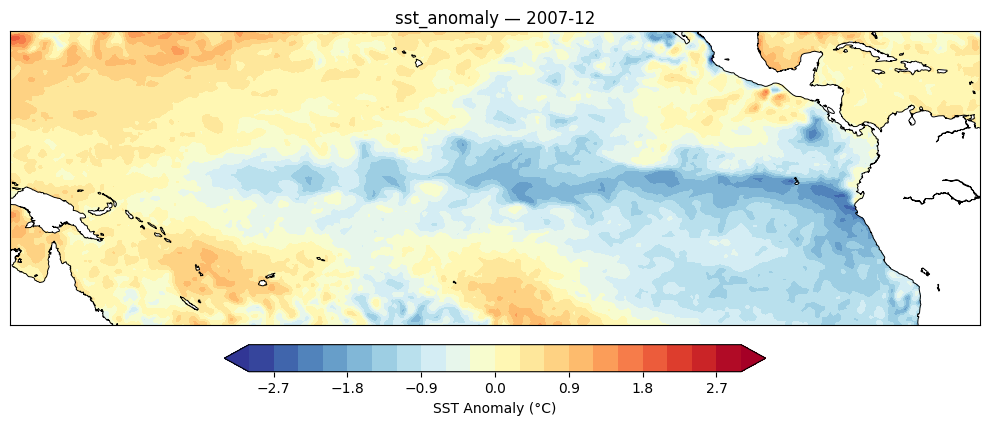

In [68]:
if True:
        fig, ax = plt.subplots(figsize=(10, 4.6))
        m = Basemap(projection="cyl",
                    llcrnrlon=lon0, urcrnrlon=lon1,
                    llcrnrlat=lat0, urcrnrlat=lat1,
                    resolution="l", ax=ax)
        m.drawcoastlines(linewidth=0.7)
        # m.drawparallels(np.arange(lat0, lat1+1, 5), labels=[1,0,0,0])
        # m.drawmeridians(np.arange(lon0, lon1+1, 10), labels=[0,0,0,1])        
        # try: m.fillcontinents(color="lightgray")
        # except Exception: pass

        cs = m.contourf(LON, LAT, Z, cmap=cmap,
             levels=np.linspace(vmin, vmax, 21), extend='both', latlon=True)
        cbar = plt.colorbar(cs, orientation="horizontal", pad=0.05, fraction=0.07)
        cbar.set_label({"sst":"SST (°C)","sst_anomaly":"SST Anomaly (°C)","level":"MHW Level","td":"Thermal Displacement (km)"}[field])
        plt.title(f"{field} — {month.strftime('%Y-%m')}")
        plt.tight_layout()
        plt.show()
